In [7]:

# Step 1: Install required libraries
# Run this in your terminal/notebook:
!pip install qrcode[pil] pillow

In [11]:
import qrcode
from PIL import Image, ImageDraw, ImageFilter
import math


def create_circular_qr(
    link: str,
    output_path: str = "qr_circular.png",
    fill_color: str = "black",
    back_color: str = "white",
    logo_path: str = None,
    logo_size_ratio: float = 0.25,      # Logo takes up 25% of QR diameter
    circle_padding: int = 30,            # Extra padding around the circle edge
    background_color: tuple = (255, 192, 203),  # Pink background (RGBA)
    add_outer_ring: bool = True,         # Decorative outer ring
    outer_ring_color: str = "black",
    box_size: int = 10,
    border: int = 4,
):
    """
    Generate a circular QR code with an optional center logo.

    Args:
        link:               URL or text to encode
        output_path:        Where to save the output PNG
        fill_color:         QR module color (default black)
        back_color:         QR background color (default white)
        logo_path:          Path to logo image (PNG recommended for transparency)
        logo_size_ratio:    Logo diameter as fraction of QR image size (0.0–0.35)
        circle_padding:     Extra pixels outside the QR square for the circle mask
        background_color:   RGBA tuple for the canvas background
        add_outer_ring:     Draw a decorative ring around the circle
        outer_ring_color:   Color of the decorative ring
        box_size:           Pixel size of each QR module
        border:             Quiet-zone modules around the QR code
    """

    # ── 1. Build the QR code ────────────────────────────────────────────────
    qr = qrcode.QRCode(
        version=1,
        error_correction=qrcode.constants.ERROR_CORRECT_H,  # High correction needed for logo
        box_size=box_size,
        border=border,
    )
    qr.add_data(link)
    qr.make(fit=True)

    qr_img = qr.make_image(fill_color=fill_color, back_color=back_color).convert("RGBA")
    qr_w, qr_h = qr_img.size
    size = max(qr_w, qr_h)                       # work on a square

    # ── 2. Create canvas with background color ──────────────────────────────
    canvas_size = size + circle_padding * 2
    canvas = Image.new("RGBA", (canvas_size, canvas_size), (0, 0, 0, 0))

    # Draw the colored circle background
    bg_layer = Image.new("RGBA", (canvas_size, canvas_size), (0, 0, 0, 0))
    bg_draw = ImageDraw.Draw(bg_layer)
    radius = canvas_size // 2
    cx, cy = canvas_size // 2, canvas_size // 2

    # Outer decorative ring
    if add_outer_ring:
        ring_width = max(6, circle_padding // 4)
        bg_draw.ellipse(
            [cx - radius, cy - radius, cx + radius - 1, cy + radius - 1],
            fill=outer_ring_color,
        )
        inner_r = radius - ring_width
        bg_draw.ellipse(
            [cx - inner_r, cy - inner_r, cx + inner_r, cy + inner_r],
            fill=background_color,
        )
    else:
        bg_draw.ellipse(
            [cx - radius, cy - radius, cx + radius - 1, cy + radius - 1],
            fill=background_color,
        )

    canvas = Image.alpha_composite(canvas, bg_layer)

    # ── 3. Paste QR onto canvas (centered) ──────────────────────────────────
    # Make the QR background transparent so only modules show
    qr_rgba = qr_img.copy()
    # Parse back_color to RGB tuple
    if isinstance(back_color, str):
        back_rgb_val = Image.new("RGB", (1, 1), back_color).getpixel((0, 0))
    else:
        back_rgb_val = back_color[:3]

    import numpy as np
    arr = np.array(qr_rgba)
    # Find pixels matching back_color (within tolerance)
    tolerance = 30
    is_back = (
        (np.abs(arr[:, :, 0].astype(int) - back_rgb_val[0]) < tolerance) &
        (np.abs(arr[:, :, 1].astype(int) - back_rgb_val[1]) < tolerance) &
        (np.abs(arr[:, :, 2].astype(int) - back_rgb_val[2]) < tolerance)
    )
    arr[:, :, 3] = np.where(is_back, 0, 255)
    qr_rgba = Image.fromarray(arr, "RGBA")

    qr_offset_x = (canvas_size - qr_w) // 2
    qr_offset_y = (canvas_size - qr_h) // 2
    canvas.paste(qr_rgba, (qr_offset_x, qr_offset_y), mask=qr_rgba)

    # ── 4. Circular crop mask ────────────────────────────────────────────────
    circle_mask = Image.new("L", (canvas_size, canvas_size), 0)
    mask_draw = ImageDraw.Draw(circle_mask)
    mask_draw.ellipse([0, 0, canvas_size - 1, canvas_size - 1], fill=255)

    # Apply circular mask
    result = Image.new("RGBA", (canvas_size, canvas_size), (0, 0, 0, 0))
    result.paste(canvas, mask=circle_mask)

    # ── 5. Add logo to center ────────────────────────────────────────────────
    if logo_path:
        try:
            logo = Image.open(logo_path).convert("RGBA")

            # Calculate logo circle size
            logo_diameter = int(canvas_size * logo_size_ratio)
            logo_radius = logo_diameter // 2

            # Create white circle background for logo
            logo_bg = Image.new("RGBA", (logo_diameter, logo_diameter), (0, 0, 0, 0))
            logo_bg_draw = ImageDraw.Draw(logo_bg)

            # White circle with slight shadow effect (draw slightly larger dark circle first)
            shadow_offset = max(2, logo_diameter // 40)
            logo_bg_draw.ellipse(
                [shadow_offset, shadow_offset, logo_diameter - 1, logo_diameter - 1],
                fill=(0, 0, 0, 80),
            )
            logo_bg_draw.ellipse(
                [0, 0, logo_diameter - shadow_offset - 1, logo_diameter - shadow_offset - 1],
                fill=(255, 255, 255, 255),
            )

            # Resize logo to fit inside the circle (with small padding)
            padding = max(4, logo_diameter // 8)
            inner_size = logo_diameter - padding * 2
            logo_resized = logo.resize((inner_size, inner_size), Image.LANCZOS)

            # Circular clip for the logo itself
            logo_clip_mask = Image.new("L", (inner_size, inner_size), 0)
            ImageDraw.Draw(logo_clip_mask).ellipse([0, 0, inner_size - 1, inner_size - 1], fill=255)
            logo_resized.putalpha(logo_clip_mask)

            # Paste logo onto white circle bg
            logo_bg.paste(logo_resized, (padding, padding), mask=logo_resized)

            # Paste the logo circle onto the center of the result
            lx = cx - logo_radius
            ly = cy - logo_radius
            result.paste(logo_bg, (lx, ly), mask=logo_bg)

            print(f"✅ Logo added from: {logo_path}")
        except FileNotFoundError:
            print(f"⚠️  Logo not found at '{logo_path}' — skipping logo.")
        except Exception as e:
            print(f"⚠️  Could not load logo: {e} — skipping logo.")
    else:
        # No logo: add a small decorative center dot instead
        dot_r = max(8, int(canvas_size * 0.03))
        dot_draw = ImageDraw.Draw(result)
        dot_draw.ellipse(
            [cx - dot_r, cy - dot_r, cx + dot_r, cy + dot_r],
            fill=fill_color,
        )

    # ── 6. Save result ───────────────────────────────────────────────────────
    result.save(output_path, format="PNG")
    print(f"✅ Circular QR code saved to: {output_path}")
    return result


Generating Minimalist Apple-style QR...


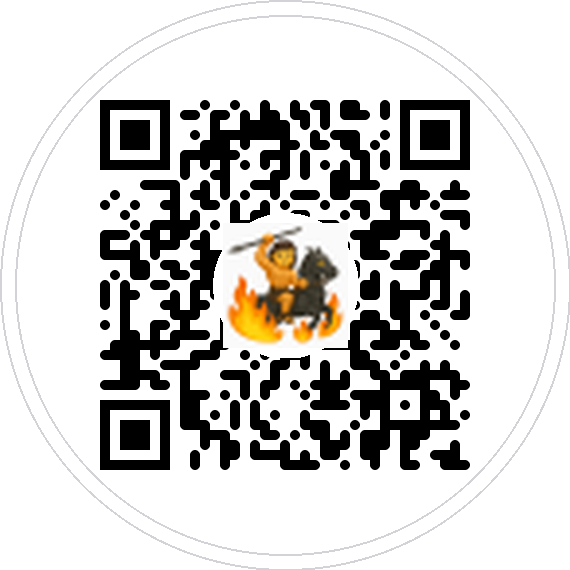

In [12]:
if __name__ == "__main__":
    LINK = "https://forms.gle/UUDbRHLBSQp5McmZA"

    print("Generating Minimalist Apple-style QR...")
    apple_qr = create_circular_qr(
        link=LINK,
        output_path="apple_minimal.png",
        logo_path="logo.png",
        fill_color="#1d1d1f",
        outer_ring_color="#d2d2d7"
    )
    display(apple_qr)